## Limpeza e Pré-processamento

In [4]:
import re
import nltk
from nltk.corpus import stopwords
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv(r'IMDB Dataset.csv')
# Download das stopwords (palavras comuns que não agregam valor ao sentimento)
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Remove tags HTML
    text = re.sub(r'<.*?>', '', text)
    # Remove caracteres especiais e números, mantendo apenas letras
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Converte para minúsculo
    text = text.lower()
    # Remove stopwords
    text = " ".join([word for word in text.split() if word not in stop_words])
    return text

df['cleaned_review'] = df['review'].apply(clean_text)

# Transformando o alvo (sentiment) em 0 e 1
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/felipe/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## vetorização

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Separando os dados
X = df['cleaned_review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Criando o vetorizador
tfidf = TfidfVectorizer(max_features=5000) # Usamos as 5000 palavras mais importantes
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

## treinamento do modelo

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Inicializando e treinando o modelo
model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

# Predições
y_pred = model.predict(X_test_tfidf)

# Resultados
print(f"Acurácia: {accuracy_score(y_test, y_pred):.2f}")
print("\nRelatório de Classificação:\n")
print(classification_report(y_test, y_pred))

Acurácia: 0.89

Relatório de Classificação:

              precision    recall  f1-score   support

           0       0.90      0.87      0.88      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



## matriz de confusao

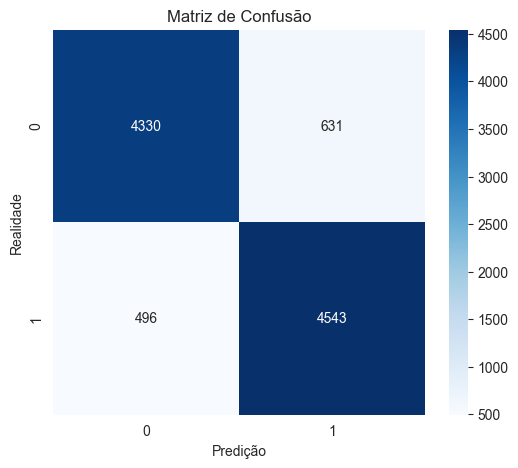

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predição')
plt.ylabel('Realidade')
plt.title('Matriz de Confusão')
plt.show()